# Exercises XP: Text Preprocessing, NER, POS, and Word2Vec


In [ ]:
%pip install --quiet spacy nltk gensim matplotlib seaborn --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 34.7 MB/s eta 0:00:00


In [ ]:
import nltk
from spacy.cli import download as spacy_download
import spacy

resources = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "tagsets",
]
for res in resources:
    nltk.download(res, quiet=True)

spacy_download("en_core_web_sm")

nlp = spacy.load("en_core_web_sm")
print("spaCy pipeline:", nlp.pipe_names)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Exercise 1 · Explore text preprocessing, NER, and POS tags

Here is the dataset you will reuse in every step.

In [ ]:
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}
raw_reviews = data['Review']
raw_reviews


["At McDonald's the food was ok and the service was bad.",
 'I would not recommend this Japanese restaurant to anyone.',
 'I loved this restaurant when I traveled to Thailand last summer.',
 'The menu of Loving has a wide variety of options.',
 "The staff was friendly and helpful at Google's employees restaurant.",
 'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
 'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
 'The sushi at Sushi Express is always fresh and flavorful.',
 'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
 'The dessert selection at Sweet Treats is to die for!']

### 1.1 Build `preprocess_text()`

In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text: str) -> str:
    # Lowercase the text
    text = text.lower()
    print(f"Original (lowercased): {text}")

    # Tokenize the text - use the function parameter 'text', not 'raw_reviews'
    tokens = nltk.word_tokenize(text)
    print(f"Tokenized ({len(tokens)} tokens): {tokens}")

    # Remove punctuation tokens (keep only alphabetic words)
    tokens = [word for word in tokens if word.isalpha()]
    print(f"Removed punctuation ({len(tokens)} tokens): {tokens}")

    # Remove stopwords
    tokens_cleaned = [word for word in tokens if word not in stop_words]
    print(f"Removed stopwords ({len(tokens_cleaned)} tokens): {tokens_cleaned}")

    # Lemmatize remaining tokens
    tokens_lemmatized = [lemmatizer.lemmatize(word) for word in tokens_cleaned]
    print(f"Lemmatized ({len(tokens_lemmatized)} tokens): {tokens_lemmatized}")

    # Join back into a single cleaned string
    cleaned_review = " ".join(tokens_lemmatized)
    print(f"Final cleaned review: {cleaned_review}")

    return cleaned_review

In [ ]:
preprocess_text(raw_reviews[0])

Original (lowercased): at mcdonald's the food was ok and the service was bad.
Tokenized (13 tokens): ['at', 'mcdonald', "'s", 'the', 'food', 'was', 'ok', 'and', 'the', 'service', 'was', 'bad', '.']
Removed punctuation (11 tokens): ['at', 'mcdonald', 'the', 'food', 'was', 'ok', 'and', 'the', 'service', 'was', 'bad']
Removed stopwords (5 tokens): ['mcdonald', 'food', 'ok', 'service', 'bad']
Lemmatized (5 tokens): ['mcdonald', 'food', 'ok', 'service', 'bad']
Final cleaned review: mcdonald food ok service bad


'mcdonald food ok service bad'

### 1.2 Create a cleaned dataset


In [ ]:
# TODO: apply preprocess_text to every review and keep both raw and cleaned versions
cleaned_reviews = [preprocess_text(text) for text in raw_reviews]

if cleaned_reviews is None:
    raise ValueError("Set cleaned_reviews by applying preprocess_text to raw_reviews.")

for raw, cleaned in zip(raw_reviews, cleaned_reviews):
    print(f"RAW: {raw}")
    print(f"CLEANED: {cleaned}\n")


Original (lowercased): at mcdonald's the food was ok and the service was bad.
Tokenized (13 tokens): ['at', 'mcdonald', "'s", 'the', 'food', 'was', 'ok', 'and', 'the', 'service', 'was', 'bad', '.']
Removed punctuation (11 tokens): ['at', 'mcdonald', 'the', 'food', 'was', 'ok', 'and', 'the', 'service', 'was', 'bad']
Removed stopwords (5 tokens): ['mcdonald', 'food', 'ok', 'service', 'bad']
Lemmatized (5 tokens): ['mcdonald', 'food', 'ok', 'service', 'bad']
Final cleaned review: mcdonald food ok service bad
Original (lowercased): i would not recommend this japanese restaurant to anyone.
Tokenized (10 tokens): ['i', 'would', 'not', 'recommend', 'this', 'japanese', 'restaurant', 'to', 'anyone', '.']
Removed punctuation (9 tokens): ['i', 'would', 'not', 'recommend', 'this', 'japanese', 'restaurant', 'to', 'anyone']
Removed stopwords (5 tokens): ['would', 'recommend', 'japanese', 'restaurant', 'anyone']
Lemmatized (5 tokens): ['would', 'recommend', 'japanese', 'restaurant', 'anyone']
Final c

### 1.3 Named Entity Recognition (NER)

In [ ]:
def perform_ner(text: str):
    """Return (entity, label) pairs found by spaCy."""
    # TODO: run the spaCy pipeline on the text
    doc = nlp(text)
    print(doc)

    entities = []
    for ent in doc.ents:
        entities.append((ent.text, ent.label_))
    return entities


In [ ]:
perform_ner(raw_reviews[2])

I loved this restaurant when I traveled to Thailand last summer.


[('Thailand', 'GPE'), ('last summer', 'DATE')]

### 1.4 Part-of-Speech tagging (POS)

In [ ]:
from nltk import pos_tag, word_tokenize

def perform_pos_tagging(text: str):
    """Return POS tags for a given text."""
    # TODO: tokenize the text
    tokens = word_tokenize(text)
    print(text)
    # TODO: call nltk.pos_tag on the tokens
    pos_tags = pos_tag(tokens)
    return pos_tags


In [ ]:
perform_pos_tagging(raw_reviews[3])

The menu of Loving has a wide variety of options.


[('The', 'DT'),
 ('menu', 'NN'),
 ('of', 'IN'),
 ('Loving', 'NNP'),
 ('has', 'VBZ'),
 ('a', 'DT'),
 ('wide', 'JJ'),
 ('variety', 'NN'),
 ('of', 'IN'),
 ('options', 'NNS'),
 ('.', '.')]

### 1.5 Apply NER and POS on raw vs cleaned text
Compare outputs on the same entries to see how preprocessing affects tagging.

In [ ]:
sample_texts = raw_reviews[:2]
sample_cleand = cleaned_reviews[:2]


print("NER on raw text")
for text in sample_texts:
    print(perform_ner(text))

print("\nNER on cleaned text")
for cleaned_text in sample_cleand:
    print(perform_ner(cleaned_text))

print("\nPOS tags on raw text")
for text in sample_texts:
    print(perform_pos_tagging(text))

print("\nPOS tags on cleaned text")
for cleaned_text in sample_cleand:
    print(perform_pos_tagging(cleaned_text))


NER on raw text
At McDonald's the food was ok and the service was bad.
[('McDonald', 'ORG')]
I would not recommend this Japanese restaurant to anyone.
[('Japanese', 'NORP')]

NER on cleaned text
mcdonald food ok service bad
[('mcdonald food ok service', 'ORG')]
would recommend japanese restaurant anyone
[('japanese', 'NORP')]

POS tags on raw text
At McDonald's the food was ok and the service was bad.
[('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]
I would not recommend this Japanese restaurant to anyone.
[('I', 'PRP'), ('would', 'MD'), ('not', 'RB'), ('recommend', 'VB'), ('this', 'DT'), ('Japanese', 'JJ'), ('restaurant', 'NN'), ('to', 'TO'), ('anyone', 'NN'), ('.', '.')]

POS tags on cleaned text
mcdonald food ok service bad
[('mcdonald', 'NNS'), ('food', 'NN'), ('ok', 'JJ'), ('service', 'NN'), ('bad', 'JJ')]
would recommend japane

## Exercise 2 · Plotting word embeddings

### 2.1 Train a Word2Vec model

In [ ]:
from gensim.models import Word2Vec

# TODO: ensure cleaned_reviews is defined from Exercise 1
print(cleaned_reviews)
# Tokenize on whitespace after preprocessing
tokenized_reviews = [review.split() for review in cleaned_reviews]
print(tokenized_reviews)
# Train the Word2Vec model
w2v_model = Word2Vec(vector_size=100, window=5, min_count=1, workers=4, sg=1)

# Build vocabulary FIRST
w2v_model.build_vocab(tokenized_reviews)

# Then train
w2v_model.train(tokenized_reviews, total_examples=len(tokenized_reviews), epochs=10)


['mcdonald food ok service bad', 'would recommend japanese restaurant anyone', 'loved restaurant traveled thailand last summer', 'menu loving wide variety option', 'staff friendly helpful google employee restaurant', 'ambiance bella italia amazing pasta dish delicious', 'terrible experience pizza hut pizza burnt service slow', 'sushi sushi express always fresh flavorful', 'steakhouse main street cozy atmosphere excellent steak', 'dessert selection sweet treat die']
[['mcdonald', 'food', 'ok', 'service', 'bad'], ['would', 'recommend', 'japanese', 'restaurant', 'anyone'], ['loved', 'restaurant', 'traveled', 'thailand', 'last', 'summer'], ['menu', 'loving', 'wide', 'variety', 'option'], ['staff', 'friendly', 'helpful', 'google', 'employee', 'restaurant'], ['ambiance', 'bella', 'italia', 'amazing', 'pasta', 'dish', 'delicious'], ['terrible', 'experience', 'pizza', 'hut', 'pizza', 'burnt', 'service', 'slow'], ['sushi', 'sushi', 'express', 'always', 'fresh', 'flavorful'], ['steakhouse', 'mai

(164, 600)

### 2.2 Inspect embedding dimensions

In [ ]:
# TODO: print the vector size and vocabulary size of your model
print(f"Vector size: {w2v_model.vector_size}")
print(f"Vocabulary size: {len(w2v_model.wv.key_to_index)}")


Vector size: 100
Vocabulary size: 55


### 2.3 Plot word embeddings

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

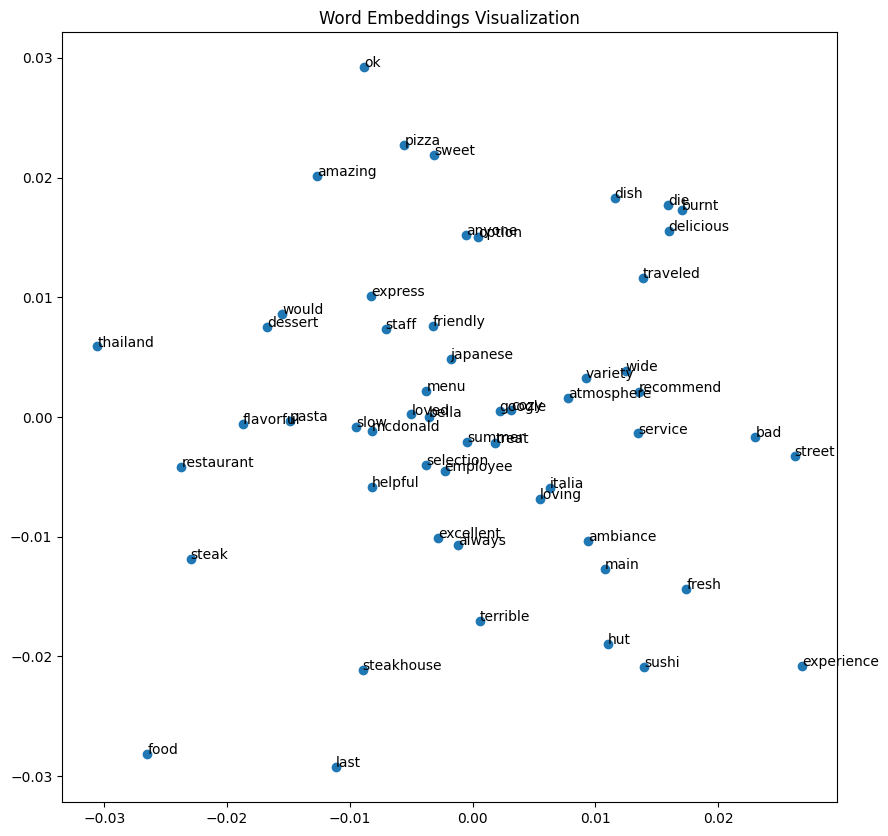

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# TODO: complete the plot_word_embeddings function
def plot_word_embeddings(model, words=None):
    plt.figure(figsize=(10, 10))
    if words is None:
        words = list(model.wv.key_to_index.keys())

    # Get vectors for the words
    vectors = [model.wv[word] for word in words if word in model.wv]

    # Use PCA to reduce to 2D
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    vectors_2d = pca.fit_transform(vectors)

    # Plot
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])

    # Annotate points with word labels
    for i, word in enumerate(words):
        if word in model.wv:
            plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))

    plt.title("Word Embeddings Visualization")
    return plt

# TODO: call the plotting function using your trained model
plot_word_embeddings(w2v_model)


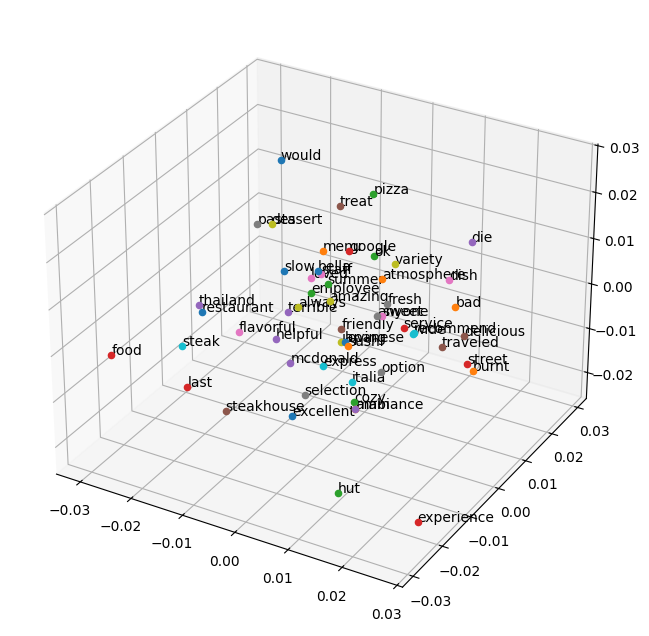

In [ ]:
# Alternative: Plot 3D (still needs reduction from 100D to 3D)
def plot_3d_embeddings(model, words=None):
    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D

    if words is None:
        words = list(model.wv.key_to_index.keys())

    # Get vectors for the words
    vectors = [model.wv[word] for word in words if word in model.wv]

    pca = PCA(n_components=3)  # Reduce to 3D
    vectors_3d = pca.fit_transform(vectors)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    for i, word in enumerate(words):
        ax.scatter(vectors_3d[i, 0], vectors_3d[i, 1], vectors_3d[i, 2])
        ax.text(vectors_3d[i, 0], vectors_3d[i, 1], vectors_3d[i, 2], word)

    plt.show()

plot_3d_embeddings(w2v_model)